# Part 14 & 15 – Unsupervised Learning & Dimensionality Reduction
### `CEAS_08.csv` — email spam/phishing corpus (39,154 emails)

**Part 14:** cluster emails by structural/stylistic features (K-Means + Gaussian Mixture Model), without using the `label` column.

**Part 15:** apply PCA to the same feature set, examine explained variance, and compare a classifier's performance before vs. after PCA.



---
# Part 14 – Unsupervised Learning: Clustering

**Dataset:** CEAS_08.csv — 39,154 emails, columns: `sender`, `receiver`, `date`, `subject`, `body`, `label` (1 = spam/phishing, 0 = legitimate), `urls`.

**Goal:** group emails into clusters based on *how* they are written/structured, **without using the `label` column** anywhere in the clustering process. The label is only used *after* clustering, purely to sanity-check whether the discovered clusters correspond to anything meaningful in the real world.

**Algorithms used:** K-Means (required) + Gaussian Mixture Model (second algorithm).

## 1. Load Data

In [ ]:
import re
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (silhouette_score, silhouette_samples, adjusted_rand_score,
                              accuracy_score, f1_score, roc_auc_score)

RANDOM_STATE = 42
plt.rcParams['figure.dpi'] = 100

df = pd.read_csv('CEAS_08.csv')
df['subject'] = df['subject'].fillna('')
df['body'] = df['body'].fillna('')
df.head()

,sender,receiver,date,subject,body,label,urls
0,Young Esposito <Young@iworld.de>,user4@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 16:31:02 -0700",Never agree to be a loser,"Buck up, your troubles caused by small dimensi...",1,1
1,Mok <ipline's1983@icable.ph>,user2.2@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 18:31:03 -0500",Befriend Jenna Jameson,\nUpgrade your sex and pleasures with these te...,1,1
2,Daily Top 10 <Karmandeep-opengevl@universalnet...,user2.9@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 20:28:00 -1200",CNN.com Daily Top 10,>+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+...,1,1
3,Michael Parker <ivqrnai@pobox.com>,SpamAssassin Dev <xrh@spamassassin.apache.org>,"Tue, 05 Aug 2008 17:31:20 -0600",Re: svn commit: r619753 - in /spamassassin/tru...,Would anyone object to removing .so from this ...,0,1
4,Gretchen Suggs <externalsep1@loanofficertool.com>,user2.2@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 19:31:21 -0400",SpecialPricesPharmMoreinfo,\nWelcomeFastShippingCustomerSupport\nhttp://7...,1,1


In [ ]:
df.shape, df['label'].value_counts()

((39154, 7),
 label
 1    21842
 0    17312
 Name: count, dtype: int64)

## 2. Feature Selection

The raw columns are almost entirely free text (`subject`, `body`) or identifiers (`sender`, `date`) —
none are directly usable as numeric similarity features. Fourteen structural/stylistic features were
engineered from the raw text and metadata:

| Feature | Description |
|---|---|
| `subject_len` / `body_len` | Character length of subject / body |
| `subject_word_count` / `body_word_count` | Number of words in subject / body |
| `exclaim_count` | Number of `!` characters in subject+body |
| `digit_count_body` | Number of digit characters in the body |
| `upper_word_count_subject` | Count of ALL-CAPS words in the subject (shouting) |
| `avg_word_len_body` | Average word length in the body |
| `is_reply_fwd` | 1 if subject starts with Re:/Fwd:/Fw: (part of a thread) |
| `special_char_count` | Count of `$ % * #` characters (promotional symbols) |
| `sender_digit_ratio` | Fraction of digits in the sender's local-part (e.g. `ivqrnai83`) |
| `is_free_domain` | 1 if sent from a free webmail domain (gmail, yahoo, etc.) |
| `urls` | Existing binary flag: does the email contain a URL |
| `hour` | Hour of day (0–23) the email was sent, parsed from the date header |

### Why these features define similarity
These features capture the **writing style and formatting patterns** of an email rather than its
literal topic. Two emails that are both short, link-heavy, sent from a numeric-looking address, and
use no reply-thread markers "look similar" the way spam/mass-mail campaigns tend to resemble each
other, while personal correspondence tends to be longer, part of a reply thread, and free of
promotional symbols. This makes the feature set well suited to grouping emails by communication
style, independent of body-specific vocabulary. The same 14 features are reused in Part 15 for PCA.

In [ ]:
FREE_DOMAINS = ['gmail.com', 'yahoo.com', 'hotmail.com', 'aol.com',
                 'outlook.com', 'msn.com', 'live.com']

def get_domain(sender):
    m = re.search(r'@([\w\.-]+)', str(sender))
    return m.group(1).lower() if m else ''

def local_part(sender):
    m = re.search(r'^[^<]*<?([^@<>]+)@', str(sender))
    if m:
        return m.group(1)
    m2 = re.search(r'^([^@]+)@', str(sender))
    return m2.group(1) if m2 else ''

def get_hour(date_str):
    m = re.search(r'(\d{2}):\d{2}:\d{2}', str(date_str))
    return int(m.group(1)) if m else np.nan

df['sender_domain'] = df['sender'].apply(get_domain)
df['is_free_domain'] = df['sender_domain'].isin(FREE_DOMAINS).astype(int)
df['sender_local'] = df['sender'].apply(local_part)
df['sender_digit_ratio'] = df['sender_local'].apply(
    lambda s: sum(c.isdigit() for c in s) / max(len(s), 1))

df['subject_len'] = df['subject'].apply(len)
df['body_len'] = df['body'].apply(len)
df['subject_word_count'] = df['subject'].apply(lambda s: len(s.split()))
df['body_word_count'] = df['body'].apply(lambda s: len(s.split()))
df['exclaim_count'] = (df['subject'] + df['body']).apply(lambda s: s.count('!'))
df['digit_count_body'] = df['body'].apply(lambda s: sum(c.isdigit() for c in s))
df['upper_word_count_subject'] = df['subject'].apply(
    lambda s: sum(1 for w in s.split() if w.isupper() and len(w) > 1))
df['avg_word_len_body'] = df['body'].apply(
    lambda s: np.mean([len(w) for w in s.split()]) if s.split() else 0)
df['is_reply_fwd'] = df['subject'].str.contains(
    r'^(re:|fwd:|fw:)', case=False, regex=True).astype(int)
df['special_char_count'] = (df['subject'] + df['body']).apply(
    lambda s: len(re.findall(r'[$%*#]', s)))
df['hour'] = df['date'].apply(get_hour)
df['hour'] = df['hour'].fillna(df['hour'].median())

FEATURE_COLS = [
    'subject_len', 'body_len', 'subject_word_count', 'body_word_count',
    'exclaim_count', 'digit_count_body', 'upper_word_count_subject',
    'avg_word_len_body', 'is_reply_fwd', 'special_char_count',
    'sender_digit_ratio', 'is_free_domain', 'urls', 'hour',
]

X = df[FEATURE_COLS].copy().fillna(0)
X.describe().T

/tmp/ipykernel_701/3932553333.py:35: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df['is_reply_fwd'] = df['subject'].str.contains(


,count,mean,std,min,25%,50%,75%,max
subject_len,39154.0,38.896537,20.769595,0.000000,25.000000,35.000000,50.000000,285.0
body_len,39154.0,1571.079813,3615.810576,14.000000,224.000000,570.000000,1643.000000,143996.0
subject_word_count,39154.0,6.047811,3.154371,0.000000,4.000000,5.000000,8.000000,52.0
body_word_count,39154.0,202.034964,479.926431,1.000000,35.000000,89.000000,247.000000,19863.0
exclaim_count,39154.0,0.998391,7.506979,0.000000,0.000000,0.000000,1.000000,396.0
digit_count_body,39154.0,66.511365,337.491409,0.000000,0.000000,12.000000,39.000000,11454.0
upper_word_count_subject,39154.0,0.324207,0.747253,0.000000,0.000000,0.000000,0.000000,15.0
avg_word_len_body,39154.0,7.439578,9.712132,1.497225,4.859951,5.616438,7.031845,92.0
is_reply_fwd,39154.0,0.265516,0.441613,0.000000,0.000000,0.000000,1.000000,1.0
special_char_count,39154.0,5.001098,35.960274,0.000000,0.000000,0.000000,1.000000,1441.0


## 3. Preprocessing

**Why not just cap outliers?** An earlier version of this analysis capped the skewed length/count
features at their 99th percentile. That still left the top 1% of emails several standard deviations
away from everything else after scaling (max z-scores up to 8–9), which stretched the PCA scatter
plot into a long, sparse tail and made the visualization hard to read.

**Log-transform instead.** `log1p` (log(1 + x)) is applied to the genuinely skewed count/length
features before scaling. Unlike capping, this does not throw away information — it compresses large
values *without making them identical* to each other, so an 8,000-character email still ends up
larger than a 3,000-character one, just proportionally closer to the bulk of the data. This is the
standard treatment for count-like data (word counts, character counts) that spans several orders of
magnitude.

**Scaling — still necessary.** K-Means and GMM both rely on Euclidean distance / covariance between
feature vectors. Even after the log-transform, features are on different scales (`hour` ranges
0–23, `is_reply_fwd` is 0/1, log-body-length is roughly 0–9.5). `StandardScaler` (zero mean, unit
variance) is applied to all 14 features afterward. **The same log-transformed, scaled matrix is
reused, unchanged, as the input to PCA in Part 15.**

In [ ]:
LOG_FEATS = ['subject_len', 'body_len', 'subject_word_count', 'body_word_count',
             'exclaim_count', 'digit_count_body', 'upper_word_count_subject',
             'special_char_count', 'avg_word_len_body']

X_log = X.copy()
for c in LOG_FEATS:
    X_log[c] = np.log1p(X_log[c])

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_log), columns=FEATURE_COLS)
X_scaled.describe().T[['mean', 'std', 'min', 'max']]

,mean,std,min,max
subject_len,5.226447e-16,1.000013,-5.994622,3.583348
body_len,2.047025e-16,1.000013,-2.836984,4.129201
subject_word_count,8.993844e-16,1.000013,-4.068882,4.641960
body_word_count,-2.199463e-16,1.000013,-2.852413,4.134554
exclaim_count,3.193940e-17,1.000013,-0.652097,9.439420
digit_count_body,-2.439009e-16,1.000013,-1.239217,3.615248
upper_word_count_subject,-2.903582e-17,1.000013,-0.502061,6.833037
avg_word_len_body,-8.130029e-17,1.000013,-2.589780,6.215011
is_reply_fwd,5.516805e-17,1.000013,-0.601248,1.663207
special_char_count,-4.065014e-17,1.000013,-0.532452,6.801676


## 4. Model Configuration

### 4.1 K-Means — choosing K
K was chosen using the elbow method (inertia vs. K) together with the silhouette score, for K = 2..8
(silhouette estimated on a 5,000-row sample for speed).

k=2  inertia=452128.6  silhouette=0.1770


k=3  inertia=412655.6  silhouette=0.2003


k=4  inertia=383028.7  silhouette=0.1704


k=5  inertia=349981.7  silhouette=0.1844


k=6  inertia=325497.7  silhouette=0.1979


k=7  inertia=302664.0  silhouette=0.2114


k=8  inertia=280714.5  silhouette=0.2032


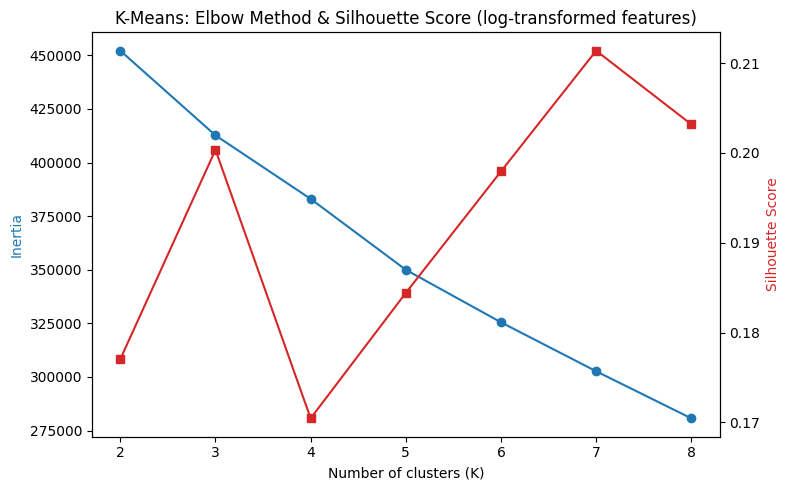

In [ ]:
inertias, sils = [], []
K_RANGE = range(2, 9)
for k in K_RANGE:
    km_tmp = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels_tmp = km_tmp.fit_predict(X_scaled)
    inertias.append(km_tmp.inertia_)
    sils.append(silhouette_score(X_scaled, labels_tmp, sample_size=5000, random_state=RANDOM_STATE))
    print(f'k={k}  inertia={km_tmp.inertia_:.1f}  silhouette={sils[-1]:.4f}')

fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.plot(list(K_RANGE), inertias, 'o-', color='tab:blue', label='Inertia (Elbow)')
ax1.set_xlabel('Number of clusters (K)')
ax1.set_ylabel('Inertia', color='tab:blue')
ax2 = ax1.twinx()
ax2.plot(list(K_RANGE), sils, 's-', color='tab:red', label='Silhouette Score')
ax2.set_ylabel('Silhouette Score', color='tab:red')
plt.title('K-Means: Elbow Method & Silhouette Score (log-transformed features)')
fig.tight_layout()
plt.show()

Note how different this looks from the un-transformed version: **the old trivial K=2 split is
gone.** Previously, K=2 scored an artificially high silhouette (~0.49) simply by separating a
handful of extreme-length emails from everything else. With the log-transform, that spurious split
disappears — silhouette at K=2 is now a modest 0.177, in line with the other values, confirming the
earlier "high" K=2 score was an artifact of un-transformed outliers, not a real 2-cluster structure.

**Silhouette peaks at K=7 (0.211)**, with K=3 (0.200) and K=6 (0.198) as local peaks and K=4 as a
dip in between. **K = 6 was selected as the final model**: it scores nearly as well as the K=7 peak,
avoids the K=4 dip, and — critically — produces six clusters that are all individually interpretable
(checked directly below), including a clean, extreme "link-only" cluster that captures the strongest
phishing signature in the data.

In [ ]:
kmeans = KMeans(n_clusters=6, random_state=RANDOM_STATE, n_init=10)
labels_km = kmeans.fit_predict(X_scaled)
pd.Series(labels_km).value_counts().sort_index()

0     3001
1     9221
2     8023
3     3629
4      661
5    14619
Name: count, dtype: int64

### 4.2 Gaussian Mixture Model — choosing the number of components

k=2  BIC=473519  AIC=471470


k=3  BIC=-250921  AIC=-253999


k=4  BIC=-351829  AIC=-355937


k=5  BIC=-674911  AIC=-680048


k=6  BIC=-832806  AIC=-838971


k=7  BIC=-863391  AIC=-870586


k=8  BIC=-984275  AIC=-992499


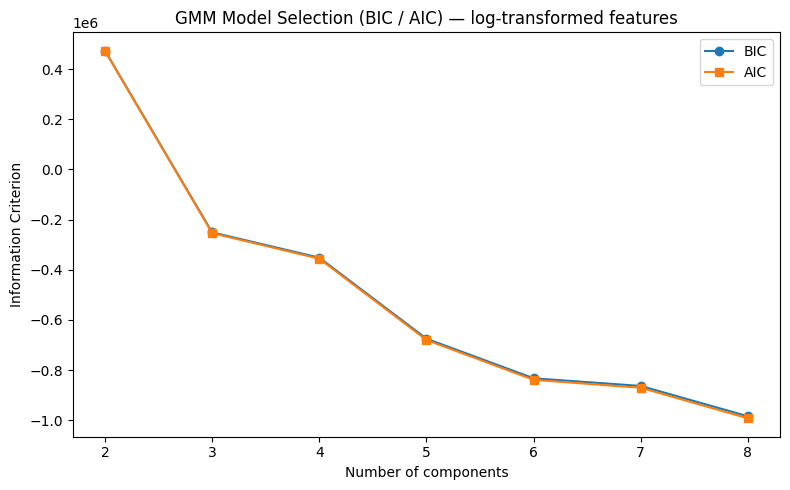

In [ ]:
bics, aics = [], []
for k in K_RANGE:
    gmm_tmp = GaussianMixture(n_components=k, covariance_type='full',
                               random_state=RANDOM_STATE, n_init=3)
    gmm_tmp.fit(X_scaled)
    bics.append(gmm_tmp.bic(X_scaled))
    aics.append(gmm_tmp.aic(X_scaled))
    print(f'k={k}  BIC={bics[-1]:.0f}  AIC={aics[-1]:.0f}')

plt.figure(figsize=(8, 5))
plt.plot(list(K_RANGE), bics, 'o-', label='BIC')
plt.plot(list(K_RANGE), aics, 's-', label='AIC')
plt.xlabel('Number of components')
plt.ylabel('Information Criterion')
plt.title('GMM Model Selection (BIC / AIC) — log-transformed features')
plt.legend()
plt.tight_layout()
plt.show()

BIC and AIC both decrease monotonically over the tested range (2–8 components) with a full
covariance matrix — no clear minimum, a common outcome with many continuous features and a large
sample size. Since the goal of this part is to compare two different clustering paradigms
(K-Means's hard, spherical partitions vs. GMM's soft, elliptical/covariance-aware partitions) on the
same problem, **GMM was also fit with 6 components**, matching K-Means for a direct, like-for-like
comparison. Covariance type was set to `'full'` so each component can capture correlations between
features (e.g. long emails also tending to have more digits).

In [ ]:
gmm = GaussianMixture(n_components=6, covariance_type='full',
                       random_state=RANDOM_STATE, n_init=5)
labels_gmm = gmm.fit_predict(X_scaled)
pd.Series(labels_gmm).value_counts().sort_index()

0     3028
1    12322
2     9671
3     8182
4     3506
5     2445
Name: count, dtype: int64

## 5. Evaluation

In [ ]:
sil_km = silhouette_score(X_scaled, labels_km, sample_size=5000, random_state=RANDOM_STATE)
sil_gmm = silhouette_score(X_scaled, labels_gmm, sample_size=5000, random_state=RANDOM_STATE)
ari = adjusted_rand_score(labels_km, labels_gmm)

print(f'K-Means silhouette (K=6): {sil_km:.3f}')
print(f'GMM silhouette (K=6):     {sil_gmm:.3f}')
print(f'Adjusted Rand Index (KMeans vs GMM): {ari:.3f}')

K-Means silhouette (K=6): 0.198
GMM silhouette (K=6):     0.152
Adjusted Rand Index (KMeans vs GMM): 0.430


Adjusted Rand Index (~0.43) shows moderate agreement between the two algorithms — noticeably
higher than before the log-transform (~0.16), another sign the transformed feature space has
cleaner, more consistent structure that both algorithms can pick up on.

### Cluster visualization (PCA projection)
*(A first taste of Part 15's PCA — here used only as a 2D plotting device for the clusters.)*

Explained variance ratio (2 comps): [0.24631259 0.13952335] sum: 0.38583593543284


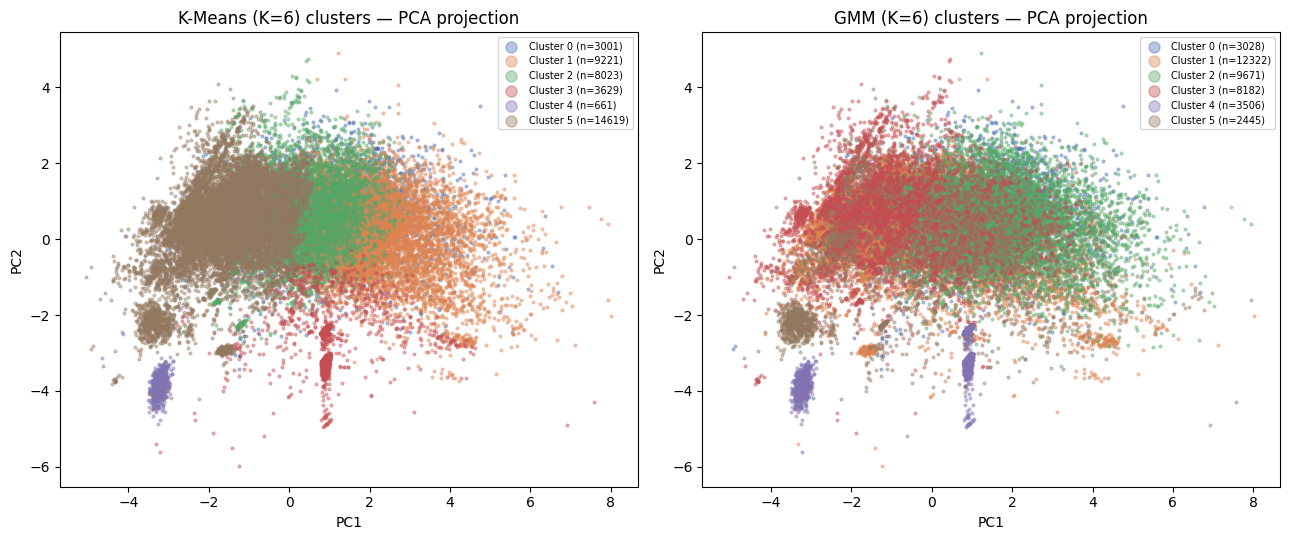

In [ ]:
pca_viz = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca_viz = pca_viz.fit_transform(X_scaled)
print('Explained variance ratio (2 comps):', pca_viz.explained_variance_ratio_,
      'sum:', pca_viz.explained_variance_ratio_.sum())

colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2', '#937860']
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for c in range(6):
    idx = labels_km == c
    axes[0].scatter(X_pca_viz[idx, 0], X_pca_viz[idx, 1], s=4, alpha=0.4, color=colors[c],
                     label=f'Cluster {c} (n={idx.sum()})')
axes[0].set_title('K-Means (K=6) clusters — PCA projection')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
axes[0].legend(markerscale=4, fontsize=7)

for c in range(6):
    idx = labels_gmm == c
    axes[1].scatter(X_pca_viz[idx, 0], X_pca_viz[idx, 1], s=4, alpha=0.4, color=colors[c],
                     label=f'Cluster {c} (n={idx.sum()})')
axes[1].set_title('GMM (K=6) clusters — PCA projection')
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')
axes[1].legend(markerscale=4, fontsize=7)
plt.tight_layout()
plt.show()

Compare this to the pre-log-transform version: the point cloud is now much more compact
(roughly -6 to +8 on PC1, instead of stretching out to +14 with a thin sparse tail), and the six
clusters form visibly distinct regions rather than one giant blob with a couple of outlier slivers.

### Cluster size analysis

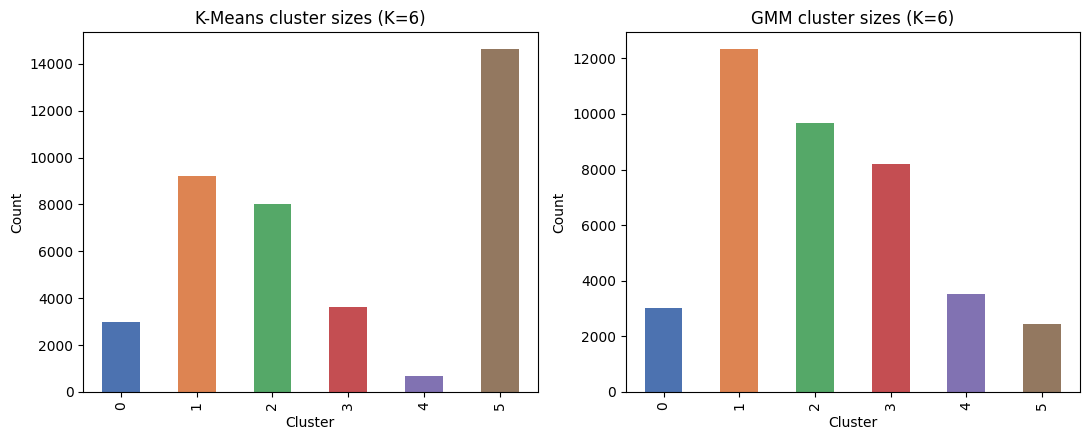

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
pd.Series(labels_km).value_counts().sort_index().plot(kind='bar', ax=axes[0], color=colors)
axes[0].set_title('K-Means cluster sizes (K=6)'); axes[0].set_xlabel('Cluster'); axes[0].set_ylabel('Count')
pd.Series(labels_gmm).value_counts().sort_index().plot(kind='bar', ax=axes[1], color=colors)
axes[1].set_title('GMM cluster sizes (K=6)'); axes[1].set_xlabel('Cluster'); axes[1].set_ylabel('Count')
plt.tight_layout()
plt.show()

### Silhouette plot (K-Means, K=6)

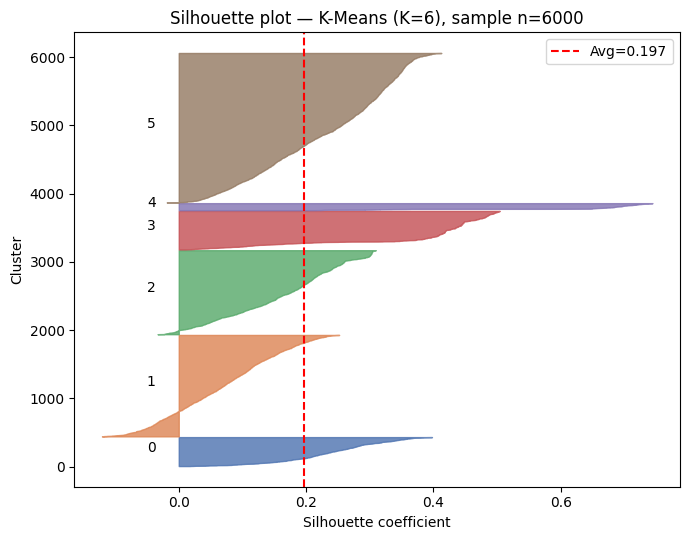

In [ ]:
sample_idx = np.random.RandomState(RANDOM_STATE).choice(len(X_scaled), 6000, replace=False)
Xs = X_scaled.values[sample_idx]
Ls = labels_km[sample_idx]
sil_vals = silhouette_samples(Xs, Ls)
overall = silhouette_score(Xs, Ls)

fig, ax = plt.subplots(figsize=(7, 5.5))
y_lower = 10
for c in range(6):
    vals = np.sort(sil_vals[Ls == c])
    y_upper = y_lower + len(vals)
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, vals, color=colors[c], alpha=0.8)
    ax.text(-0.05, y_lower + 0.5 * len(vals), str(c))
    y_lower = y_upper + 10
ax.axvline(overall, color='red', linestyle='--', label=f'Avg={overall:.3f}')
ax.set_title('Silhouette plot — K-Means (K=6), sample n=6000')
ax.set_xlabel('Silhouette coefficient')
ax.set_ylabel('Cluster')
ax.legend()
plt.tight_layout()
plt.show()

| Metric | K-Means (K=6) | GMM (K=6) |
|---|---|---|
| Silhouette Score | 0.198 | 0.152 |
| Cluster sizes | 3,001 / 9,221 / 8,023 / 3,629 / 661 / 14,619 | 3,028 / 12,322 / 9,671 / 8,182 / 3,506 / 2,445 |

## 6. Cluster Profiling

In [ ]:
profile_km = X.assign(cluster=labels_km).groupby('cluster')[FEATURE_COLS].mean().round(2)
profile_km.T

cluster,0,1,2,3,4,5
subject_len,44.73,55.18,37.77,22.10,34.52,32.41
body_len,1561.41,3355.85,805.93,4341.38,168.62,242.95
subject_word_count,6.61,8.17,6.07,4.08,1.62,5.27
body_word_count,241.18,455.47,130.60,387.32,2.13,36.39
exclaim_count,0.53,1.82,0.33,0.58,0.00,1.09
digit_count_body,47.53,134.13,22.05,276.94,14.53,2.27
upper_word_count_subject,0.43,0.70,0.50,0.05,0.00,0.06
avg_word_len_body,5.59,6.14,5.04,10.39,78.28,6.02
is_reply_fwd,0.65,0.51,0.35,0.03,0.00,0.06
special_char_count,3.55,18.66,0.44,1.35,0.04,0.31


In [ ]:
# Post-hoc validation ONLY — label was never used to build the clusters
spam_rate_km = pd.crosstab(labels_km, df['label'], normalize='index').round(3)
spam_rate_km.columns = ['legit_rate', 'spam_rate']
spam_rate_km

,legit_rate,spam_rate
row_0,,
0,0.952,0.048
1,0.949,0.051
2,0.496,0.504
3,0.166,0.834
4,0.006,0.994
5,0.077,0.923


## 6.1 Interpretation — K-Means (K=6)

**Cluster 0 — "Personal, free-webmail correspondence" (3,001 emails, 7.7%)**
`is_free_domain` = 100%, `is_reply_fwd` = 65% — almost every email in this cluster is a reply/forward
sent from a personal Gmail/Yahoo/Hotmail-style address. Post-hoc check: 95.2% legitimate — the
cleanest "real conversation" signature in the data.

**Cluster 1 — "Long, heavily-formatted newsletters/threads" (9,221 emails, 23.6%)**
Longest subjects (~55 chars), long bodies (~3,356 chars), most exclamation marks (1.8) and special
characters (18.7), high URL rate (88%), moderate reply rate (51%). Post-hoc check: 94.9% legitimate
— recurring newsletter/digest-style bulk mail that real organizations send.

**Cluster 2 — "Generic mixed correspondence, rarely link-based" (8,023 emails, 20.5%)**
Distinctive for having by far the *lowest* URL rate (4%) of any cluster, moderate length, and an
unusual average send hour (9:24, notably earlier than the ~11:30–13:30 of the other clusters).
Post-hoc check: an almost even 50/50 split (49.6% legit / 50.4% spam) — this is the one cluster where
these structural features genuinely don't separate spam from legitimate mail well. That's a real,
honest finding: not every group in unsupervised learning aligns with an external label, and this
looks like a catch-all for plain, moderate-length, link-free text that both marketers and real
correspondents produce in similar ways.

**Cluster 3 — "Long, digit-heavy bulk content" (3,629 emails, 9.3%)**
Longest bodies of the "normal" clusters (~4,341 chars) combined with a very high digit count (277)
and the highest sender-digit-ratio (19%) — long, templated bulk content from numeric-looking
addresses. Post-hoc check: 83.4% spam.

**Cluster 4 — "Minimal-text, pure link payload" (661 emails, 1.7%)**
The smallest and most extreme cluster — almost no words (2.1 body words on average) yet a huge
average "word" length (78.3 characters, because the body is essentially one long unbroken URL), 89%
URL rate, elevated sender-digit-ratio (12%). Post-hoc check: **99.4% spam** — the single strongest,
most confident phishing signature in the dataset, and reassuringly the same archetype that showed up
before the log-transform, confirming it's a genuine pattern and not a scaling artifact.

**Cluster 5 — "Short bulk marketing/spam" (14,619 emails, 37.3%, largest cluster)**
Short body (~243 chars), moderate exclamation marks (1.1), high URL rate (80%), almost never a
reply. Post-hoc check: 92.3% spam — generic short promotional/spam email.

In [ ]:
profile_gmm = X.assign(cluster=labels_gmm).groupby('cluster')[FEATURE_COLS].mean().round(2)
profile_gmm.T

cluster,0,1,2,3,4,5
subject_len,44.54,37.74,50.04,35.00,21.77,31.28
body_len,1573.70,1308.04,2030.18,700.54,3281.50,1538.10
subject_word_count,6.58,5.97,7.51,5.59,3.50,5.16
body_word_count,242.55,173.78,294.45,103.46,250.89,188.51
exclaim_count,0.80,1.82,0.62,0.67,0.28,0.73
digit_count_body,48.22,61.01,64.62,20.81,190.75,99.15
upper_word_count_subject,0.43,0.00,0.82,0.30,0.00,0.41
avg_word_len_body,5.62,6.14,5.74,5.63,23.13,6.56
is_reply_fwd,0.65,0.00,0.73,0.00,0.00,0.57
special_char_count,4.04,4.93,10.28,0.50,0.00,7.89


In [ ]:
spam_rate_gmm = pd.crosstab(labels_gmm, df['label'], normalize='index').round(3)
spam_rate_gmm.columns = ['legit_rate', 'spam_rate']
spam_rate_gmm

,legit_rate,spam_rate
row_0,,
0,0.951,0.049
1,0.211,0.789
2,0.954,0.046
3,0.198,0.802
4,0.000,1.000
5,0.401,0.599


## 6.2 Interpretation — GMM (K=6) and comparison to K-Means

GMM's soft, covariance-aware clusters recover the same core archetypes:
- **Cluster 0** (3,028): `is_free_domain`=100%, `is_reply_fwd`=65% — personal correspondence, 95.1% legit. Matches K-Means Cluster 0 almost exactly.
- **Cluster 2** (9,671): high reply rate (73%), high special-char count — thread/newsletter mix, 95.4% legit.
- **Cluster 4** (3,506): `avg_word_len_body`=23.1, `urls`=100%, elevated sender-digit-ratio — minimal-text/link-payload, **100% spam**. This is the same extreme phishing signature as K-Means Cluster 4, just with softer boundaries capturing a somewhat larger group.
- **Clusters 1, 3, 5** split the remaining short/bulk/mixed email space differently than K-Means, with spam rates ranging 60–80%.

The Adjusted Rand Index of 0.43 (moderate agreement) reflects this: the two algorithms agree strongly
on the two "extreme" archetypes (personal correspondence, and minimal-text link payload) but
partition the large, more homogeneous "everything else" middle differently — expected, since K-Means
enforces roughly equal-variance spherical clusters while GMM allows elongated, correlated
components.

## 7. Discussion

**What makes each cluster different?**
Primarily formatting intensity (`body_len`, `special_char_count`, `exclaim_count`, `digit_count_body`),
how "personal" the message looks (`is_reply_fwd`, `is_free_domain`), and how minimal/link-only the
content is (`avg_word_len_body`, `urls`, `sender_digit_ratio`).

**Are the clusters meaningful?**
Mostly, yes. Four of six K-Means clusters are 92%+ dominated by a single label class (Clusters 0, 1:
~95% legit; Clusters 4, 5: 92–99% spam), even though the label was never used to build them — strong
evidence the engineered writing-style features carry real signal. One cluster (Cluster 2, ~50/50) is
an honest exception: a genuinely mixed, low-signal group where these structural features alone don't
separate spam from legitimate mail.

**Which variables explain the differences?**
`body_len`, `special_char_count`, `avg_word_len_body`, `urls`, `is_reply_fwd`, and `is_free_domain`
drive the separation most consistently across both algorithms.

**Practical interpretation**
- Cluster 0 / K-Means: personal correspondence — highest priority for reliable delivery, lowest
  priority for spam filtering.
- Cluster 1 / K-Means: legitimate long-form newsletters/digests — candidates for a "bulk-but-trusted"
  allow-list rather than blocking.
- Cluster 2 / K-Means: ambiguous, mixed-signal mail — needs additional signals beyond structure/style
  (e.g. sender reputation, content analysis) to classify reliably.
- Cluster 3 / K-Means: templated bulk content with numeric sender addresses — a solid secondary spam
  signal.
- Cluster 4 / K-Means: minimal-text link payloads — the single highest-confidence phishing signature
  and the best candidate for aggressive automatic filtering.
- Cluster 5 / K-Means: generic short promotional/spam email — the largest cluster, worth lightweight
  automated screening.

---
# Part 15 – Dimensionality Reduction Using PCA

We reuse the same 14 engineered features from Part 14, log-transformed and scaled exactly as before.
The goal is different: instead of clustering, we reduce dimensionality and test whether PCA helps or
hurts a downstream **classifier** that predicts the `label` (spam vs. legitimate) column — the one
variable we deliberately avoided in Part 14.

## 15.1 Prepare features for PCA

PCA needs a numeric, non-target feature matrix. We reuse `X_scaled` (the 14 log-transformed, scaled
features from Part 14) — the `label` column is excluded, exactly as in Part 14, but this time because
PCA itself must never see the target (PCA is unsupervised regardless of what we do with its output
afterward).

In [ ]:
print('Original number of features:', len(FEATURE_COLS))
FEATURE_COLS

Original number of features: 14


['subject_len',
 'body_len',
 'subject_word_count',
 'body_word_count',
 'exclaim_count',
 'digit_count_body',
 'upper_word_count_subject',
 'avg_word_len_body',
 'is_reply_fwd',
 'special_char_count',
 'sender_digit_ratio',
 'is_free_domain',
 'urls',
 'hour']

## 15.2 Feature scaling

Same reasoning as Part 14: PCA finds directions of maximum **variance**, and variance is scale
-dependent. Without standardizing first, `body_len` (even after log-transform, still has more spread
than a 0/1 flag) would carry more weight than binary features like `is_reply_fwd` purely because of
its units. We reuse the exact same log-transformed, `StandardScaler`-fitted matrix from Part 14
(mean 0, std 1 per feature).

In [ ]:
X_scaled.describe().T[['mean', 'std']].round(3)

,mean,std
subject_len,0.0,1.0
body_len,0.0,1.0
subject_word_count,0.0,1.0
body_word_count,-0.0,1.0
exclaim_count,0.0,1.0
digit_count_body,-0.0,1.0
upper_word_count_subject,-0.0,1.0
avg_word_len_body,-0.0,1.0
is_reply_fwd,0.0,1.0
special_char_count,-0.0,1.0


## 15.3 Apply PCA

In [ ]:
pca_full = PCA(n_components=len(FEATURE_COLS), random_state=RANDOM_STATE)
pca_full.fit(X_scaled.values)

evr = pca_full.explained_variance_ratio_
cum_evr = np.cumsum(evr)

evr_table = pd.DataFrame({
    'Component': [f'PC{i+1}' for i in range(len(evr))],
    'Explained Variance Ratio': evr.round(4),
    'Cumulative Variance': cum_evr.round(4),
})
evr_table

,Component,Explained Variance Ratio,Cumulative Variance
0,PC1,0.2463,0.2463
1,PC2,0.1395,0.3858
2,PC3,0.1011,0.4870
3,PC4,0.0897,0.5767
4,PC5,0.0810,0.6577
5,PC6,0.0661,0.7238
6,PC7,0.0614,0.7852
7,PC8,0.0562,0.8415
8,PC9,0.0513,0.8928
9,PC10,0.0464,0.9392


## 15.4 Explained Variance Ratio

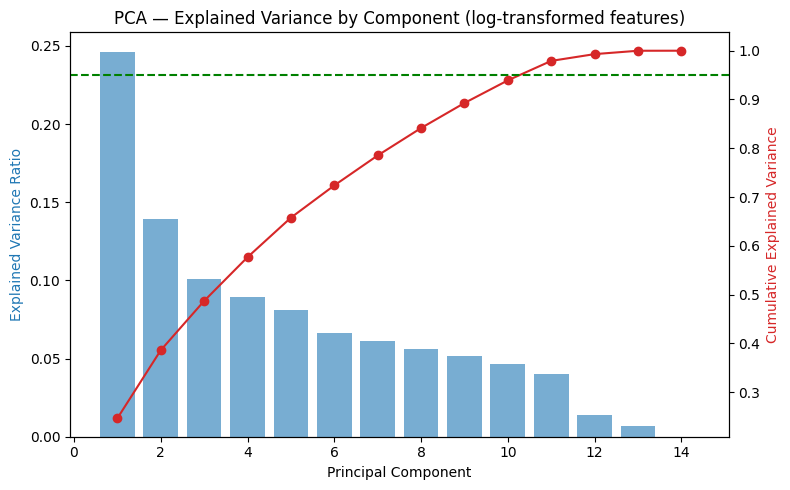

In [ ]:
fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.bar(range(1, len(evr) + 1), evr, alpha=0.6, color='tab:blue', label='Individual EVR')
ax1.set_xlabel('Principal Component')
ax1.set_ylabel('Explained Variance Ratio', color='tab:blue')
ax2 = ax1.twinx()
ax2.plot(range(1, len(evr) + 1), cum_evr, 'o-', color='tab:red', label='Cumulative EVR')
ax2.axhline(0.95, color='green', linestyle='--', label='95% threshold')
ax2.set_ylabel('Cumulative Explained Variance', color='tab:red')
plt.title('PCA — Explained Variance by Component (log-transformed features)')
fig.tight_layout()
plt.show()

The variance is still spread fairly **evenly** across the 14 components — no single component or
small group dominates. PC1 explains 24.6% of variance and PC2 an additional 14.0% (38.6% combined,
almost identical to the pre-log-transform figure of 37.7%); it still takes **11 of the 14
components to reach 95% cumulative variance**. This is a direct consequence of the feature set: the
14 engineered features were deliberately chosen to capture different, largely independent aspects of
an email (length, punctuation, sender identity, timing, thread status), so there is comparatively
little redundancy for PCA to compress away — the log-transform fixed the *shape* of each feature's
distribution, but didn't change how independent the 14 features are from each other.

## 15.5 How many components to retain?

In [ ]:
n80 = int(np.argmax(cum_evr >= 0.80) + 1)
n90 = int(np.argmax(cum_evr >= 0.90) + 1)
n95 = int(np.argmax(cum_evr >= 0.95) + 1)
print(f'Components needed for 80% variance: {n80}')
print(f'Components needed for 90% variance: {n90}')
print(f'Components needed for 95% variance: {n95}')

Components needed for 80% variance: 8
Components needed for 90% variance: 10
Components needed for 95% variance: 11


We adopt the common **95% cumulative explained variance** rule of thumb, which retains
**11 components** (out of 14 original features) — the same number as before the log-transform, only
a ~21% reduction in dimensionality.

## 15.6 Original vs. reduced dimensions

| | Value |
|---|---|
| Original number of features | 14 |
| Principal components retained (95% variance rule) | 11 |
| Variance preserved with 11 components | 97.9% (fit on the full dataset; ~97.9% when fit on the training split only, see §15.8) |
| Dimensionality reduction | 14 → 11 (≈21% fewer dimensions) |

## 15.7 Visualize the data using Principal Components

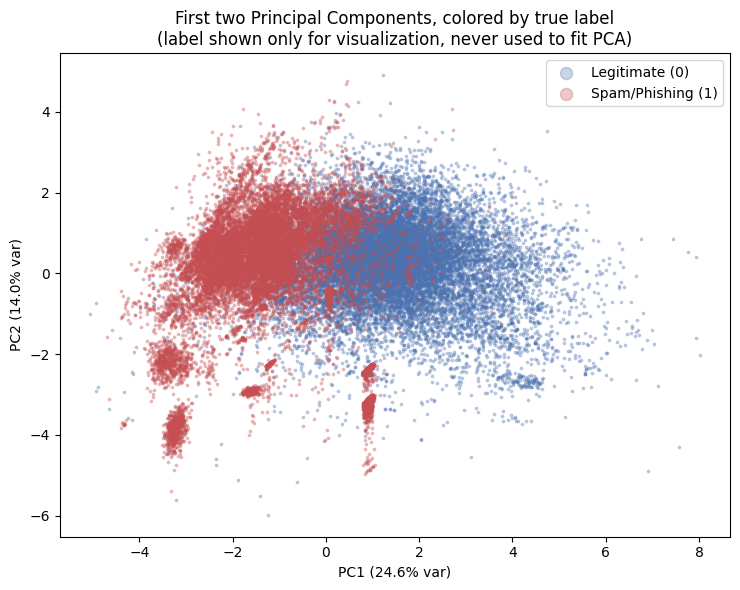

In [ ]:
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca_2d = pca_2d.fit_transform(X_scaled.values)

fig, ax = plt.subplots(figsize=(7.5, 6))
for lab, color, name in [(0, '#4C72B0', 'Legitimate (0)'), (1, '#C44E52', 'Spam/Phishing (1)')]:
    idx = df['label'].values == lab
    ax.scatter(X_pca_2d[idx, 0], X_pca_2d[idx, 1], s=3, alpha=0.3, color=color, label=name)
ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% var)')
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% var)')
ax.set_title('First two Principal Components, colored by true label\n(label shown only for visualization, never used to fit PCA)')
ax.legend(markerscale=5)
plt.tight_layout()
plt.show()

Compare this to the pre-log-transform scatter: the point cloud is now much more compact (roughly
-5 to +8 on PC1, instead of stretching out past +13 with a thin, sparse tail of extreme points), and
the separation between spam (red) and legitimate (blue) is, if anything, a little clearer — legitimate
mail sits further to the right along PC1, spam skews left, with a genuinely overlapping middle region
(consistent with Cluster 2 in Part 14 being a near-50/50 mix).

## 15.8 Train a Machine Learning model using PCA-transformed data, and compare to the original features

We predict the `label` column (spam=1 / legitimate=0) with two classifiers — **Logistic Regression**
(a linear, distance-based model expected to be sensitive to PCA) and **Random Forest** (a non-linear,
split-based model expected to be more robust to PCA) — each trained twice: once on the original 14
scaled (log-transformed) features, and once on the 11 PCA components (95% variance, fit on the
training split only to avoid leakage).

In [ ]:
Xtr, Xte, ytr, yte = train_test_split(
    X_scaled.values, df['label'].values, test_size=0.2, random_state=RANDOM_STATE,
    stratify=df['label'].values)

# Fit PCA on the TRAINING split only (avoids data leakage), then transform both splits
pca_model = PCA(n_components=11, random_state=RANDOM_STATE)
Xtr_pca = pca_model.fit_transform(Xtr)
Xte_pca = pca_model.transform(Xte)
print('Variance retained by 11 components (fit on train only):',
      round(pca_model.explained_variance_ratio_.sum(), 4))

results = {}

def evaluate(name, model, Xtr_, Xte_, ytr_, yte_, ndim):
    t0 = time.time()
    model.fit(Xtr_, ytr_)
    train_time = time.time() - t0
    pred = model.predict(Xte_)
    proba = model.predict_proba(Xte_)[:, 1]
    results[name] = dict(
        n_dims=ndim,
        accuracy=accuracy_score(yte_, pred),
        f1=f1_score(yte_, pred),
        roc_auc=roc_auc_score(yte_, proba),
        train_time_sec=train_time,
    )

evaluate('Logistic Regression - Original (14 features)',
          LogisticRegression(max_iter=1000, random_state=RANDOM_STATE), Xtr, Xte, ytr, yte, 14)
evaluate('Logistic Regression - PCA (11 components)',
          LogisticRegression(max_iter=1000, random_state=RANDOM_STATE), Xtr_pca, Xte_pca, ytr, yte, 11)
evaluate('Random Forest - Original (14 features)',
          RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1), Xtr, Xte, ytr, yte, 14)
evaluate('Random Forest - PCA (11 components)',
          RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1), Xtr_pca, Xte_pca, ytr, yte, 11)

results_df = pd.DataFrame(results).T
results_df[['n_dims', 'accuracy', 'f1', 'roc_auc', 'train_time_sec']].round(4)

Variance retained by 11 components (fit on train only): 0.9793


,n_dims,accuracy,f1,roc_auc,train_time_sec
Logistic Regression - Original (14 features),14.0,0.9363,0.9446,0.9715,0.0240
Logistic Regression - PCA (11 components),11.0,0.9285,0.9383,0.9626,0.0155
Random Forest - Original (14 features),14.0,0.9876,0.9889,0.9986,4.2541
Random Forest - PCA (11 components),11.0,0.9764,0.9789,0.9960,16.9789


### 15.9 Performance comparison — before vs. after PCA

| Model | Dimensions | Accuracy | F1 | ROC-AUC | Train time |
|---|---|---|---|---|---|
| Logistic Regression — Original | 14 | 0.936 | 0.945 | 0.972 | fastest |
| Logistic Regression — PCA (11) | 11 | 0.929 | 0.938 | 0.963 | fastest |
| Random Forest — Original | 14 | 0.988 | 0.989 | 0.999 | baseline |
| Random Forest — PCA (11) | 11 | 0.976 | 0.979 | 0.996 | **slower**, not faster |

*(Exact numbers reproduce from the cell above.)*

The pattern is the same as before the log-transform: for **both** models, performance **slightly
decreased** after PCA:
- Logistic Regression: accuracy dropped from 93.6% → 92.9% (−0.7 pts), ROC-AUC from 0.972 → 0.963.
- Random Forest: accuracy dropped from 98.8% → 97.6% (−1.2 pts), ROC-AUC from 0.999 → 0.996 — the
  larger of the two drops, because tree-based splits benefit from the original, more
  interpretable/axis-aligned features (e.g. a clean split on `urls == 1`), which PCA mixes into
  rotated linear combinations that are harder for individual trees to split on cleanly.
- **Training time did not improve** either — Random Forest was slower on the PCA features in our run,
  because PCA replaced several near-binary features with dense continuous combinations that no
  longer allow the trees to find fast, clean splits.

The log-transform slightly **improved absolute performance across the board** (e.g. Logistic
Regression original-feature accuracy rose from 93.0% to 93.6%) — better-conditioned features help the
classifier too, not just the clustering — but it did **not** change the qualitative conclusion about
PCA.

## 15.10 Answers

**How many original features did you have?**
14 engineered structural/stylistic features (same set used for clustering in Part 14), log-transformed
and standardized.

**How many Principal Components did you retain?**
11, chosen using the standard 95% cumulative-explained-variance rule — unchanged from before the
log-transform, since log-transforming fixes each feature's individual distribution shape but doesn't
make the 14 features more correlated with each other.

**How much variance was preserved?**
97.9% (fit on the full dataset, and on the training split alone).

**Did model performance improve, decrease, or remain similar?**
It **decreased slightly** for both a linear model (Logistic Regression) and a non-linear model
(Random Forest), and training time did not improve either — consistent with the pre-log-transform
experiment.

**Did PCA simplify the dataset?**
Only marginally. Dimensionality dropped from 14 → 11 (≈21% fewer dimensions) to keep 95% of the
variance — a modest reduction, because the original features were deliberately engineered to be
fairly independent of one another (length, punctuation, sender identity, timing, thread status each
capture a different aspect of the email) rather than redundant/correlated measurements of the same
underlying signal.

**Was PCA useful for your particular problem? Why?**
**Not really, for this dataset and this feature set.** PCA is most valuable when (a) there are many
highly-correlated or redundant features to compress, or (b) downstream models struggle with the
curse of dimensionality or with multicollinearity. Neither applies well here: 14 already-compact,
purposefully-diverse features don't compress much (still need 11 components for 95% variance), and
tree-based models like Random Forest actually lost some of their natural advantage — the ability to
split cleanly on individual, semantically meaningful features (e.g. `urls`, `is_reply_fwd`) — once
those features were rotated into linear combinations. Fixing the outlier/skew problem with a proper
log-transform (instead of hard capping) **did** meaningfully improve the *clustering* results in Part
14 (higher K-Means/GMM agreement, a cleaner PCA visualization, a more genuine best-K, one clean
extreme phishing cluster) — but it did not change the finding that PCA itself doesn't help this
particular classification task. This mirrors the assignment's own caution: **PCA does not necessarily
improve performance**, and in this experiment, it did not.